
PHASE 0: Load dataset and split into clients
[12:57:34] [INFO] Detected 23 classes: ['Bacha (Pangasius bocourti)', 'Baim(ব্যাইম)     (Mastacembelus armatus)', 'Bele(বেলে)  (Glossogobius giuris)', 'Chada(চাদা)      (Pseudambassis ranga)', 'Cheng(চ্যাঙ) (Channa harcourtbutleri)', 'Dairka(Esomus danrica)', 'Dhaira(ঢাইর\u200d্যা) (Botia dario)', 'Dhyala-pithali(ঢেলা)    (Osteobrama cotio cotio)', 'Fasa(ফাসা)         (Setipinna phasa)', 'Goti(গোটি)       (Channa striata)', 'Guchi(গুচি)        (Mastacembelus pancalus)', 'Itha(ইঠ্যা)           (velvet catfishes)', 'Kakila(কাকিল্যা)    (Xenentodon cancila)', 'Khori(খরি)          (Gonialosa)', 'Mohola(মলা)        (Amblypharyngodon mola)', 'Pabda(পাব্দা)       (Ompok pabda)', 'Piyali (Aspidoparia jaya)', 'Puthi(পুটি)         (Puntius sophore)', 'Rewa( রেওয়া)       (Cirrhinus reba)', 'Veda(ভ্যাদা) (Nundus Meni)', 'jiyol(জিওল-শিং)   (Heteropneustes fossilis)', 'koi(কই)            (Anabas testudineus)', 'paloa tengra(ট্যাংরা)    (Batasio tengana

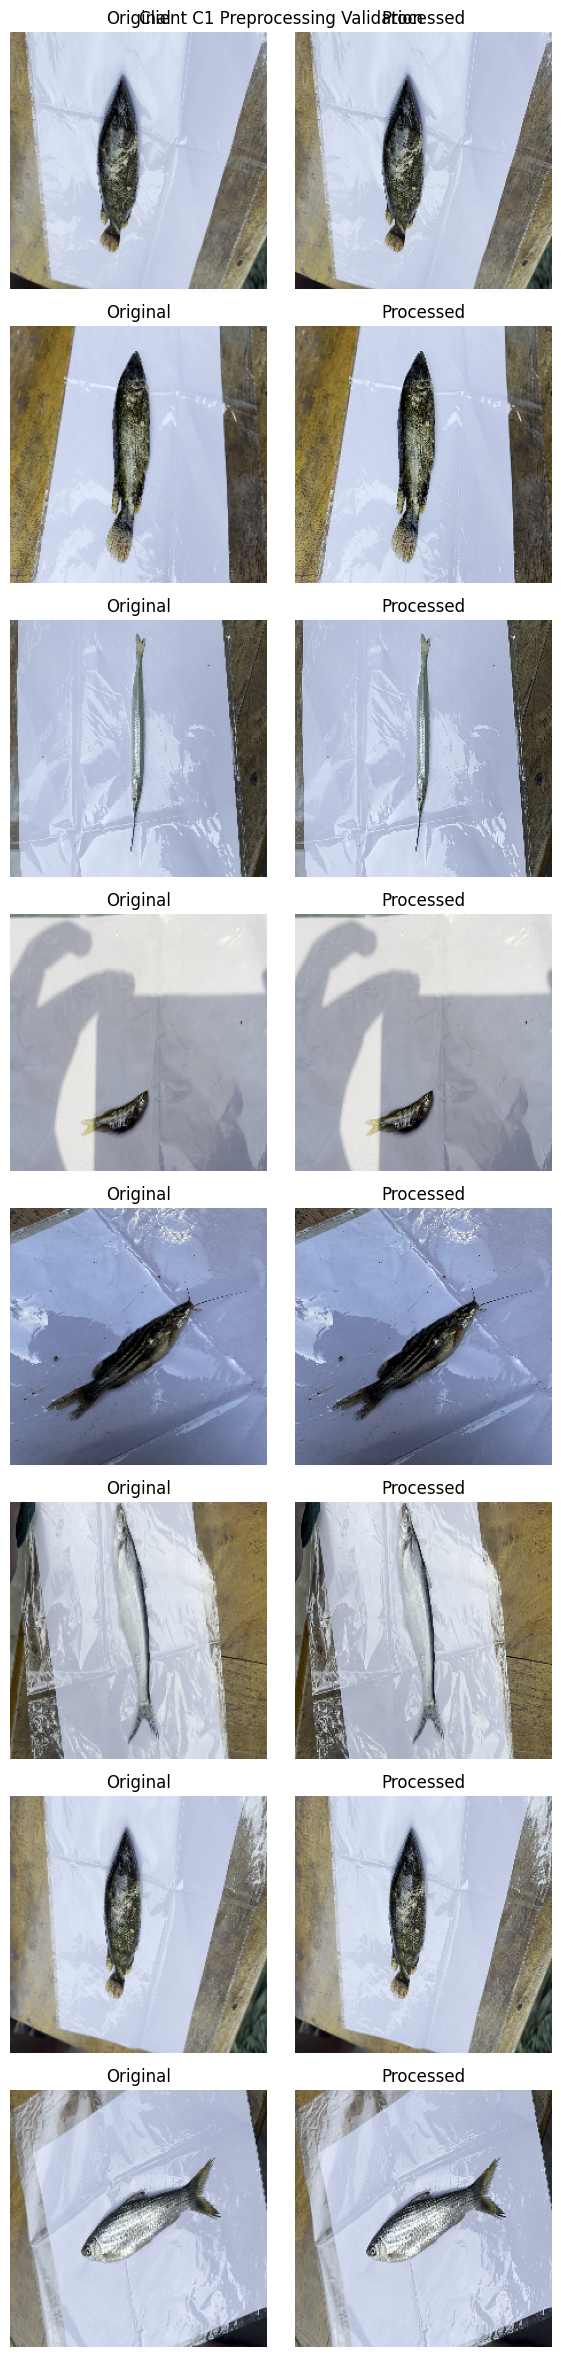

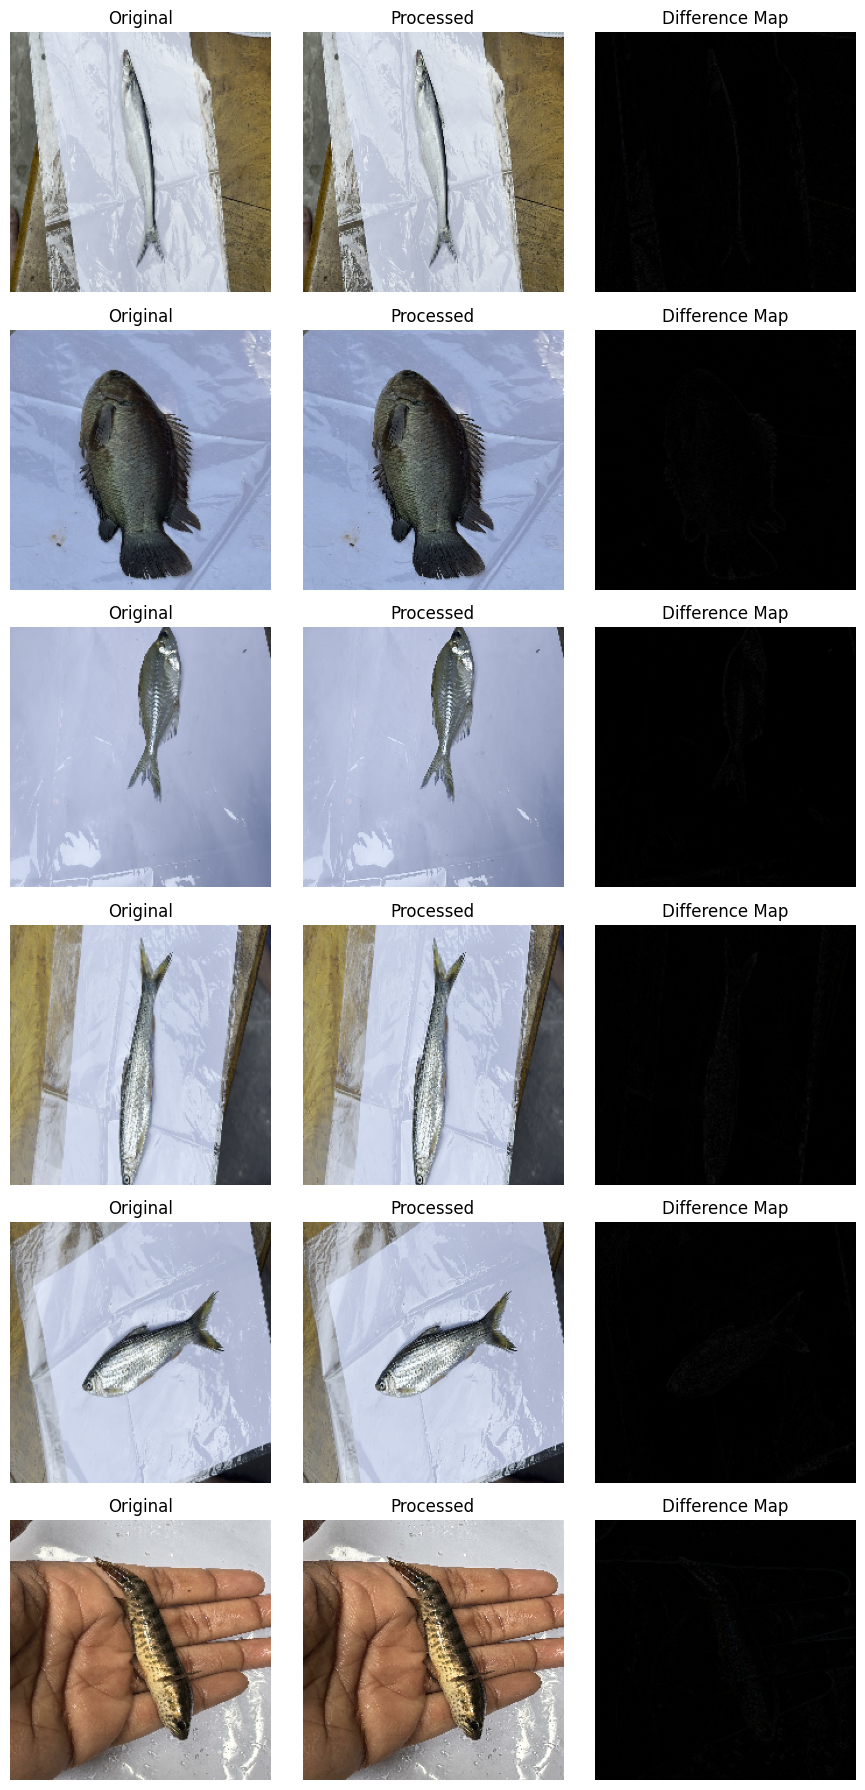

[13:59:14] [INFO] GA consistency run 1/3 for Client C1
[14:00:08] [INFO] C1 Gen 1/6 | BestScoreSoFar=0.5860 | EliteTop=0.5860
[14:01:00] [INFO] C1 Gen 2/6 | BestScoreSoFar=0.5875 | EliteTop=0.5875
[14:01:52] [INFO] C1 Gen 3/6 | BestScoreSoFar=0.5965 | EliteTop=0.5965
[14:02:44] [INFO] C1 Gen 4/6 | BestScoreSoFar=0.6025 | EliteTop=0.6025
[14:03:36] [INFO] C1 Gen 5/6 | BestScoreSoFar=0.6025 | EliteTop=0.6025
[14:04:28] [INFO] C1 Gen 6/6 | BestScoreSoFar=0.6025 | EliteTop=0.6008
[14:04:28] [INFO] C1 FINAL best proxy score = 0.6025 | pipeline length = 1
[14:04:28] [INFO] C1 PIPELINE: SHARPEN(factor=1.379)
[14:04:28] [INFO] GA consistency run 2/3 for Client C1
[14:05:22] [INFO] C1 Gen 1/6 | BestScoreSoFar=0.5833 | EliteTop=0.5833
[14:06:14] [INFO] C1 Gen 2/6 | BestScoreSoFar=0.5981 | EliteTop=0.5981
[14:07:06] [INFO] C1 Gen 3/6 | BestScoreSoFar=0.5986 | EliteTop=0.5986
[14:07:59] [INFO] C1 Gen 4/6 | BestScoreSoFar=0.6028 | EliteTop=0.6028
[14:08:51] [INFO] C1 Gen 5/6 | BestScoreSoFar=0.6028

[[('SHARPEN', {'factor': 1.3789915961343797})],
 [('SHARPEN', {'factor': 1.4871542134017868})],
 [('SHARPEN', {'factor': 1.1079373107385502})]]

In [4]:
# ============================================================
# FedPIGD-B v2 (Debug + Detailed Logging) with MobileNetV2
# Fixes: tf.image.resize "images contains no shape"
# Adds: strong logging + correct FedAvg aggregation
# ============================================================

import os
import time
import copy
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageEnhance, ImageFilter
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)
from sklearn.preprocessing import label_binarize

# ============================================================
# 0) CONFIG
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "/Users/sabbirahmed/Downloads/Rafi/train_data_no_aug"
TEST_DIR  = "/Users/sabbirahmed/Downloads/Rafi/Fish/test_data"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
LR = 1e-4
DROPOUT = 0.3

NUM_CLIENTS = 4
FL_ROUNDS = 10
LOCAL_EPOCHS_PER_ROUND = 1

EV_POP = 10
EV_GENS = 6
EV_SUBSET = 256
MAX_PIPE_LEN = 5

ANCHOR_LAMBDA = 1e-3

# Logging granularity
LOG_EVERY_BATCH = 20   # print batch loss every N batches
LOG_PIPELINE_OPS = True

# ============================================================
# LOGGING HELPERS
# ============================================================
def ts():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{ts()}] [INFO] {msg}")

def warn(msg):
    print(f"[{ts()}] [WARN] {msg}")

def phase(title):
    print("\n" + "=" * 72)
    print(f"{title}")
    print("=" * 72)

def pretty_pipeline(pipe):
    parts = []
    for (op, p) in pipe:
        if not p:
            parts.append(op)
        else:
            kv = ",".join([f"{k}={round(v,3)}" for k,v in p.items()])
            parts.append(f"{op}({kv})")
    return " -> ".join(parts)

# ============================================================
# 1) LOAD DATA (paths only)
# ============================================================
phase("PHASE 0: Load dataset and split into clients")

def list_classes(train_dir):
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    return classes, {c: i for i, c in enumerate(classes)}

def load_paths_labels(data_dir, class_to_idx):
    paths, labels = [], []
    for cls, idx in class_to_idx.items():
        cls_path = os.path.join(data_dir, cls)
        files = os.listdir(cls_path)
        for fn in files:
            if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_path, fn))
                labels.append(idx)
    return np.array(paths), np.array(labels)

def split_clients(paths, labels, n=4):
    idx = np.random.permutation(len(paths))
    paths, labels = paths[idx], labels[idx]
    proportions = np.random.dirichlet([1.0]*n)
    sizes = (proportions * len(paths)).astype(int)
    sizes[-1] = len(paths) - np.sum(sizes[:-1])

    out = []
    s = 0
    for i, sz in enumerate(sizes):
        cp = paths[s:s+sz]
        cl = labels[s:s+sz]
        out.append((cp, cl))
        log(f"Client C{i+1}: {sz} samples")
        s += sz
    return out

class_names, class_to_idx = list_classes(TRAIN_DIR)
K = len(class_names)
log(f"Detected {K} classes: {class_names}")

train_paths, train_labels = load_paths_labels(TRAIN_DIR, class_to_idx)
test_paths,  test_labels  = load_paths_labels(TEST_DIR,  class_to_idx)

log(f"Train total: {len(train_paths)} | Test total: {len(test_paths)}")
clients = split_clients(train_paths, train_labels, NUM_CLIENTS)

# ============================================================
# 2) NON-DIFFERENTIABLE PIPELINE OPS (PIL) + TF wrapper
# ============================================================
phase("PHASE 1: Define non-differentiable preprocessing program space (PIL)")

OP_SPACE = ["IDENTITY", "GRAYSCALE", "AUTO_CONTRAST", "EQUALIZE",
            "SHARPEN", "BRIGHTNESS", "CONTRAST", "BLUR"]

def sample_op():
    op = random.choice(OP_SPACE)
    params = {}
    if op in ["SHARPEN", "BRIGHTNESS", "CONTRAST"]:
        params["factor"] = float(np.random.uniform(0.8, 1.5))
    if op == "BLUR":
        params["radius"] = float(np.random.uniform(0.2, 1.5))
    return (op, params)

def apply_op(img_pil, op):
    name, p = op
    if name == "GRAYSCALE":
        return ImageOps.grayscale(img_pil).convert("RGB")
    if name == "AUTO_CONTRAST":
        return ImageOps.autocontrast(img_pil)
    if name == "EQUALIZE":
        return ImageOps.equalize(img_pil)
    if name == "SHARPEN":
        return ImageEnhance.Sharpness(img_pil).enhance(p["factor"])
    if name == "BRIGHTNESS":
        return ImageEnhance.Brightness(img_pil).enhance(p["factor"])
    if name == "CONTRAST":
        return ImageEnhance.Contrast(img_pil).enhance(p["factor"])
    if name == "BLUR":
        return img_pil.filter(ImageFilter.GaussianBlur(radius=p["radius"]))
    return img_pil

def apply_pipeline_np(img_float01, pipeline):
    # img_float01: float32 [0..1]
    img_uint8 = (np.clip(img_float01, 0.0, 1.0) * 255).astype(np.uint8)
    img = Image.fromarray(img_uint8)
    for op in pipeline:
        img = apply_op(img, op)
    out = np.array(img).astype(np.float32) / 255.0
    return out

def tf_apply_pipeline(img_float01, pipeline):
    out = tf.numpy_function(lambda z: apply_pipeline_np(z, pipeline), [img_float01], tf.float32)
    out.set_shape([IMAGE_SIZE[0], IMAGE_SIZE[1], 3])  # IMPORTANT: force known shape
    return out

log(f"Operator space: {OP_SPACE}")
log("Pipeline executed via PIL inside tf.numpy_function (non-differentiable by design).")

# ============================================================
# 3) SAFE DECODE + RESIZE (FIXES 'images contains no shape')
# ============================================================
phase("PHASE 1B: Safe decode/resize pipeline (fix shape error)")

def decode_and_resize(path_tensor):
    """
    Safe decoder:
      - tf.io.read_file -> tf.image.decode_image
      - force known rank/channels using set_shape([None, None, 3])
      - then resize
    """
    raw = tf.io.read_file(path_tensor)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])  # ✅ FIX: give resize a known rank
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

log("decode_and_resize(): decode_image + set_shape([None,None,3]) + resize ✅")

# ============================================================
# 4) YOUR BASE MODEL (MobileNetV2 frozen) + adapter + head
# ============================================================
phase("PHASE 0 (Model): Build MobileNetV2 backbone (frozen) + adapter + head")

def build_model(num_classes):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )
    base.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(128, activation="relu", name="adapter")(x)  # adapters
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(num_classes, activation="softmax", name="head")(x)

    model = tf.keras.Model(inputs=base.input, outputs=out)
    return model, base

def build_feature_extractor(backbone):
    return tf.keras.Model(
        inputs=backbone.input,
        outputs=tf.keras.layers.GlobalAveragePooling2D()(backbone.output)
    )

global_model, backbone = build_model(K)
feat_model = build_feature_extractor(backbone)

log("Model built.")
log("Backbone frozen. Trainables are adapter + head.")

# ============================================================
# 5) PHASE 1: EVOLUTION WITH SEPARABILITY PROXY
# ============================================================
phase("PHASE 1: Local preprocessing evolution per client (proxy fitness)")

def separability_proxy(features, labels):
    # between-class scatter / within-class scatter
    labels = labels.astype(int)
    overall = features.mean(axis=0, keepdims=True)

    sb = 0.0
    sw = 0.0
    for c in np.unique(labels):
        Xc = features[labels == c]
        if len(Xc) < 2:
            continue
        mc = Xc.mean(axis=0, keepdims=True)
        sb += len(Xc) * np.sum((mc - overall) ** 2)
        sw += np.sum((Xc - mc) ** 2)
    return float(sb / (sw + 1e-8))

def evolve_pipeline_for_client(client_id, c_paths, c_labels):
    # init population
    pop = []
    for _ in range(EV_POP):
        L = random.randint(1, MAX_PIPE_LEN)
        pop.append([sample_op() for _ in range(L)])

    best_pipe = None
    best_score = -1e9

    for g in range(EV_GENS):
        scored = []
        # sample subset
        n = min(EV_SUBSET, len(c_paths))
        idx = np.random.choice(len(c_paths), size=n, replace=False) if len(c_paths) > n else np.arange(len(c_paths))
        sub_paths = c_paths[idx]
        sub_labels = c_labels[idx]

        # pre-load subset once per generation (faster logging)
        # We still apply pipeline per candidate (novelty preserved)
        for pi, pipe in enumerate(pop):
            xs = []
            for pth in sub_paths:
                x = decode_and_resize(tf.constant(pth))
                x = tf_apply_pipeline(x, pipe)
                xs.append(x.numpy())
            xs = np.array(xs, dtype=np.float32)

            feats = feat_model.predict(xs, verbose=0)
            score = separability_proxy(feats, sub_labels) - 0.02 * len(pipe)  # length penalty

            scored.append((score, pipe))
            if score > best_score:
                best_score = score
                best_pipe = pipe

        scored.sort(key=lambda x: x[0], reverse=True)
        elites = [p for _, p in scored[:max(2, EV_POP//3)]]

        log(f"C{client_id} Gen {g+1}/{EV_GENS} | BestScoreSoFar={best_score:.4f} | EliteTop={scored[0][0]:.4f}")

        # breed next generation
        new_pop = elites.copy()
        while len(new_pop) < EV_POP:
            parent = copy.deepcopy(random.choice(elites))
            # simple mutation
            if random.random() < 0.4 and len(parent) < MAX_PIPE_LEN:
                parent.append(sample_op())
            else:
                parent[random.randrange(len(parent))] = sample_op()
            new_pop.append(parent)
        pop = new_pop

    log(f"C{client_id} FINAL best proxy score = {best_score:.4f} | pipeline length = {len(best_pipe)}")
    if LOG_PIPELINE_OPS:
        log(f"C{client_id} PIPELINE: {pretty_pipeline(best_pipe)}")
    return best_pipe

client_pipelines = []
for i, (cp, cl) in enumerate(clients, start=1):
    log(f"Start evolution for Client C{i} (samples={len(cp)})")
    pipe = evolve_pipeline_for_client(i, cp, cl)
    client_pipelines.append(pipe)

# ============================================================
# 6) PHASE 2: SIGNATURES
# ============================================================
phase("PHASE 2: Build pipeline signatures and send to server")

def pipeline_signature(pipe):
    hist = np.zeros(len(OP_SPACE), dtype=np.float32)
    factors = []
    radii = []

    for (op, p) in pipe:
        hist[OP_SPACE.index(op)] += 1.0
        if "factor" in p:
            factors.append(float(p["factor"]))
        if "radius" in p:
            radii.append(float(p["radius"]))

    f_mean = np.mean(factors) if factors else 0.0
    f_std  = np.std(factors) if factors else 0.0
    r_mean = np.mean(radii) if radii else 0.0
    r_std  = np.std(radii) if radii else 0.0
    length = float(len(pipe))
    runtime_proxy = length

    sig = np.concatenate([hist, np.array([f_mean, f_std, r_mean, r_std, length, runtime_proxy], dtype=np.float32)], axis=0)
    return sig

client_sigs = np.stack([pipeline_signature(p) for p in client_pipelines], axis=0)
log(f"Signature dim = {client_sigs.shape[1]}")
log(f"Signatures shape = {client_sigs.shape} (clients x dim)")

# ============================================================
# 7) PHASE 3+4: FL + SIGNATURE-CONDITIONED ANCHORING
# ============================================================
phase("PHASE 3+4: Federated training + signature-conditioned anchoring (with detailed logs)")

def get_adapter_vector(model):
    w = model.get_layer("adapter").get_weights()  # [kernel, bias]
    return np.concatenate([w[0].ravel(), w[1].ravel()], axis=0).astype(np.float32)

def set_adapter_from_vector(model, vec):
    layer = model.get_layer("adapter")
    w = layer.get_weights()
    k_shape = w[0].shape
    b_shape = w[1].shape
    k_size = int(np.prod(k_shape))
    kernel = vec[:k_size].reshape(k_shape)
    bias   = vec[k_size:k_size+int(np.prod(b_shape))].reshape(b_shape)
    layer.set_weights([kernel, bias])

def get_trainable_tensors(model):
    # adapter kernel, adapter bias, head kernel, head bias
    return model.get_layer("adapter").weights + model.get_layer("head").weights

def extract_trainable_numpy(model):
    return [w.numpy() for w in get_trainable_tensors(model)]

def assign_trainable_numpy(model, new_vals):
    for var, val in zip(get_trainable_tensors(model), new_vals):
        var.assign(val)

def fedavg(trainable_sets, sizes):
    total = float(sum(sizes))
    avg = []
    for wi in range(len(trainable_sets[0])):
        acc = 0.0
        for ci in range(len(trainable_sets)):
            acc += (sizes[ci] / total) * trainable_sets[ci][wi]
        avg.append(acc)
    return avg

# Conditioner: signature -> adapter anchor vector (Ridge, stable with 4 clients)
class ConditionerRidge:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.models = None

    def fit(self, S, A):
        # Fit one ridge per output dimension (simple multi-output)
        self.models = [Ridge(alpha=self.alpha).fit(S, A[:, j]) for j in range(A.shape[1])]

    def predict(self, s):
        s = s.reshape(1, -1)
        out = np.array([m.predict(s)[0] for m in self.models], dtype=np.float32)
        return out

conditioner = ConditionerRidge(alpha=1.0)

# initialize anchors as the current global adapter vector (stable start)
anchors = [get_adapter_vector(global_model).copy() for _ in range(NUM_CLIENTS)]
log("Anchors initialized from global adapter vector.")

def make_client_dataset(paths, labels, pipeline, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(2000, len(paths)), seed=SEED, reshuffle_each_iteration=True)

    # freeze pipeline into default argument so autograph doesn't capture loop var
    def map_fn(x, y, pipe=pipeline):
        img = decode_and_resize(x)
        img = tf_apply_pipeline(img, pipe)
        return img, y

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Eager training loop with heavy logging
def train_one_epoch_with_anchor(model, dataset, optimizer, anchor_vec, lam, client_id, round_id):
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    adapter_layer = model.get_layer("adapter")
    kernel_var, bias_var = adapter_layer.weights

    anchor_tf = tf.convert_to_tensor(anchor_vec, dtype=tf.float32)

    total_loss = 0.0
    steps = 0

    for xb, yb in dataset:
        with tf.GradientTape() as tape:
            probs = model(xb, training=True)
            ce = loss_fn(yb, probs)

            k_flat = tf.reshape(kernel_var, [-1])
            b_flat = tf.reshape(bias_var, [-1])
            cur_vec = tf.concat([k_flat, b_flat], axis=0)

            anchor_loss = tf.reduce_sum(tf.square(cur_vec - anchor_tf))
            loss = ce + lam * anchor_loss

        grads = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        total_loss += float(loss.numpy())
        steps += 1

        if steps % LOG_EVERY_BATCH == 0:
            log(f"[Round {round_id}] C{client_id} batch={steps} | loss={total_loss/steps:.4f} (CE+anchor)")

    return total_loss / max(steps, 1)

# ---------- FL ROUNDS ----------
for r in range(1, FL_ROUNDS + 1):
    phase(f"FL ROUND {r}/{FL_ROUNDS}")

    global_weights = global_model.get_weights()
    local_trainables = []
    sizes = []
    local_adapter_centers = []

    for ci, (cp, cl) in enumerate(clients, start=1):
        log(f"Client C{ci}: build local model + sync global weights")
        local_model, _ = build_model(K)
        local_model.set_weights(global_weights)

        # Drift before training
        cur_vec = get_adapter_vector(local_model)
        drift = float(np.linalg.norm(cur_vec - anchors[ci-1]))
        log(f"Client C{ci}: adapter drift before train = {drift:.6f}")

        # dataset
        log(f"Client C{ci}: build dataset with client pipeline")
        ds = make_client_dataset(cp, cl, client_pipelines[ci-1], shuffle=True)

        # train
        opt = tf.keras.optimizers.Adam(LR)
        avg_loss = train_one_epoch_with_anchor(
            local_model, ds, opt,
            anchor_vec=anchors[ci-1],
            lam=ANCHOR_LAMBDA,
            client_id=ci,
            round_id=r
        )
        log(f"Client C{ci}: epoch done | avg loss={avg_loss:.4f}")

        # collect updates
        local_trainables.append(extract_trainable_numpy(local_model))
        sizes.append(len(cp))

        # adapter center for conditioner update
        local_adapter_centers.append(get_adapter_vector(local_model))

    # Server aggregation (FedAvg) for adapter+head only
    log("Server: FedAvg aggregate adapter+head updates")
    avg_trainables = fedavg(local_trainables, sizes)
    assign_trainable_numpy(global_model, avg_trainables)
    log("Server: global model updated (adapter+head).")

    # Server conditioner update: signature -> adapter anchor
    log("Server: update conditioner (signature -> adapter anchor)")
    A = np.stack(local_adapter_centers, axis=0)  # [clients, adapter_dim]
    conditioner.fit(client_sigs, A)
    anchors = [conditioner.predict(client_sigs[i]) for i in range(NUM_CLIENTS)]
    log("Server: anchors refreshed for next round.")

phase("FINAL EVALUATION: Test set (no client preprocessing)")

def make_test_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def map_fn(x, y):
        img = decode_and_resize(x)
        return img, y

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

# ---------------------------
# Predict
# ---------------------------
test_ds = make_test_dataset(test_paths, test_labels)
pred_probs = global_model.predict(test_ds, verbose=1)
preds = np.argmax(pred_probs, axis=1)

# ---------------------------
# Basic metrics
# ---------------------------
acc  = accuracy_score(test_labels, preds)
prec = precision_score(test_labels, preds, average="weighted", zero_division=0)
rec  = recall_score(test_labels, preds, average="weighted", zero_division=0)
f1   = f1_score(test_labels, preds, average="weighted", zero_division=0)
ll   = log_loss(test_labels, pred_probs)

# ---------------------------
# ROC-AUC + PR-AUC (multiclass OvR)
# ---------------------------
y_true_bin = label_binarize(test_labels, classes=list(range(K)))

roc_auc = roc_auc_score(
    y_true_bin,
    pred_probs,
    average="macro",
    multi_class="ovr"
)

pr_auc = average_precision_score(
    y_true_bin,
    pred_probs,
    average="macro"
)

# ---------------------------
# Print results
# ---------------------------
log(f"Accuracy     = {acc:.4f}")
log(f"Precision    = {prec:.4f} (weighted)")
log(f"Recall       = {rec:.4f} (weighted)")
log(f"F1-score     = {f1:.4f} (weighted)")
log(f"ROC-AUC      = {roc_auc:.4f} (macro, OvR)")
log(f"PR-AUC       = {pr_auc:.4f} (macro)")
log(f"Log-Loss     = {ll:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, preds, target_names=class_names, digits=4))


from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(test_labels, preds)
log(f"MCC Score    = {mcc:.4f}")



def visualize_before_after(paths, pipeline, n=8, title="Before / After"):
    sel = np.random.choice(len(paths), size=n, replace=False)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))

    for i, idx in enumerate(sel):
        img = decode_and_resize(tf.constant(paths[idx])).numpy()
        proc = tf_apply_pipeline(tf.constant(img), pipeline).numpy()

        axes[i,0].imshow(img)
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(proc)
        axes[i,1].set_title("Processed")
        axes[i,1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_before_after(
    clients[0][0],
    client_pipelines[0],
    title="Client C1 Preprocessing Validation"
)

def visualize_difference_map(paths, pipeline, n=6):
    sel = np.random.choice(len(paths), size=n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))

    for i, idx in enumerate(sel):
        img = decode_and_resize(tf.constant(paths[idx])).numpy()
        proc = tf_apply_pipeline(tf.constant(img), pipeline).numpy()
        diff = np.abs(proc - img)

        axes[i,0].imshow(img)
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(proc)
        axes[i,1].set_title("Processed")
        axes[i,1].axis("off")

        axes[i,2].imshow(diff, cmap="hot")
        axes[i,2].set_title("Difference Map")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_difference_map(
    clients[0][0],
    client_pipelines[0]
)


def compare_multiple_ga_runs(client_id, cp, cl, runs=3):
    pipes = []
    for r in range(runs):
        log(f"GA consistency run {r+1}/{runs} for Client C{client_id}")
        pipe = evolve_pipeline_for_client(client_id, cp, cl)
        pipes.append(pipe)

    for i, p in enumerate(pipes):
        log(f"Run {i+1} pipeline: {pretty_pipeline(p)}")

    return pipes

compare_multiple_ga_runs(
    client_id=1,
    cp=clients[0][0],
    cl=clients[0][1],
    runs=3
)
